# Pipeline 3 - Create the reference mask

## Imports


In [1]:
%load_ext autoreload
%autoreload 2

from swot_toolkit.pipe2 import open_output_dir
from swot_toolkit.pipe3 import create_random_samples, open_s2_img

OUTPUT_DIR = "/data/swot/output/Rio_Branco"

aoi, s2_ids = open_output_dir(OUTPUT_DIR)

s2_ids

Reading KML file: /data/swot/output/Rio_Branco/kml/Rio_Branco.kml


{'2025-09-07': 'S2C_MSIL2A_20250911T142731_R053_T20MPE_20250911T174714',
 '2024-08-27': 'S2B_MSIL2A_20240822T142709_R053_T20MPE_20240822T212947'}

In [2]:
DATE = "2025-09-07"

In [3]:
s2_img, scl = open_s2_img(s2_ids[DATE], OUTPUT_DIR)

## Create Random Samples

Create a first set of control  points and save it to `"training_samples"` folder.

/workspaces/swot/.venv/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


<Axes: >

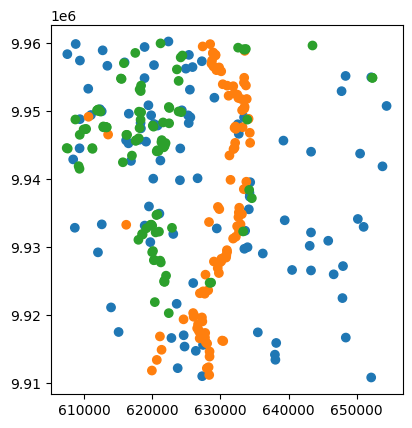

In [ ]:
scl_samples_df = create_random_samples(scl, output_dir=OUTPUT_DIR)
scl_samples_df.plot(column="class", cmap="tab10", vmin=0, vmax=10)

## Create the reference mask

In [8]:
import matplotlib.pyplot as plt

from swot_toolkit.pipe3 import create_ref_mask

In [9]:
full_pred = create_ref_mask(s2_img, OUTPUT_DIR, _id=s2_ids[DATE])

Using 305 training samples.
Training the RF classifier...
Predicting the full image...


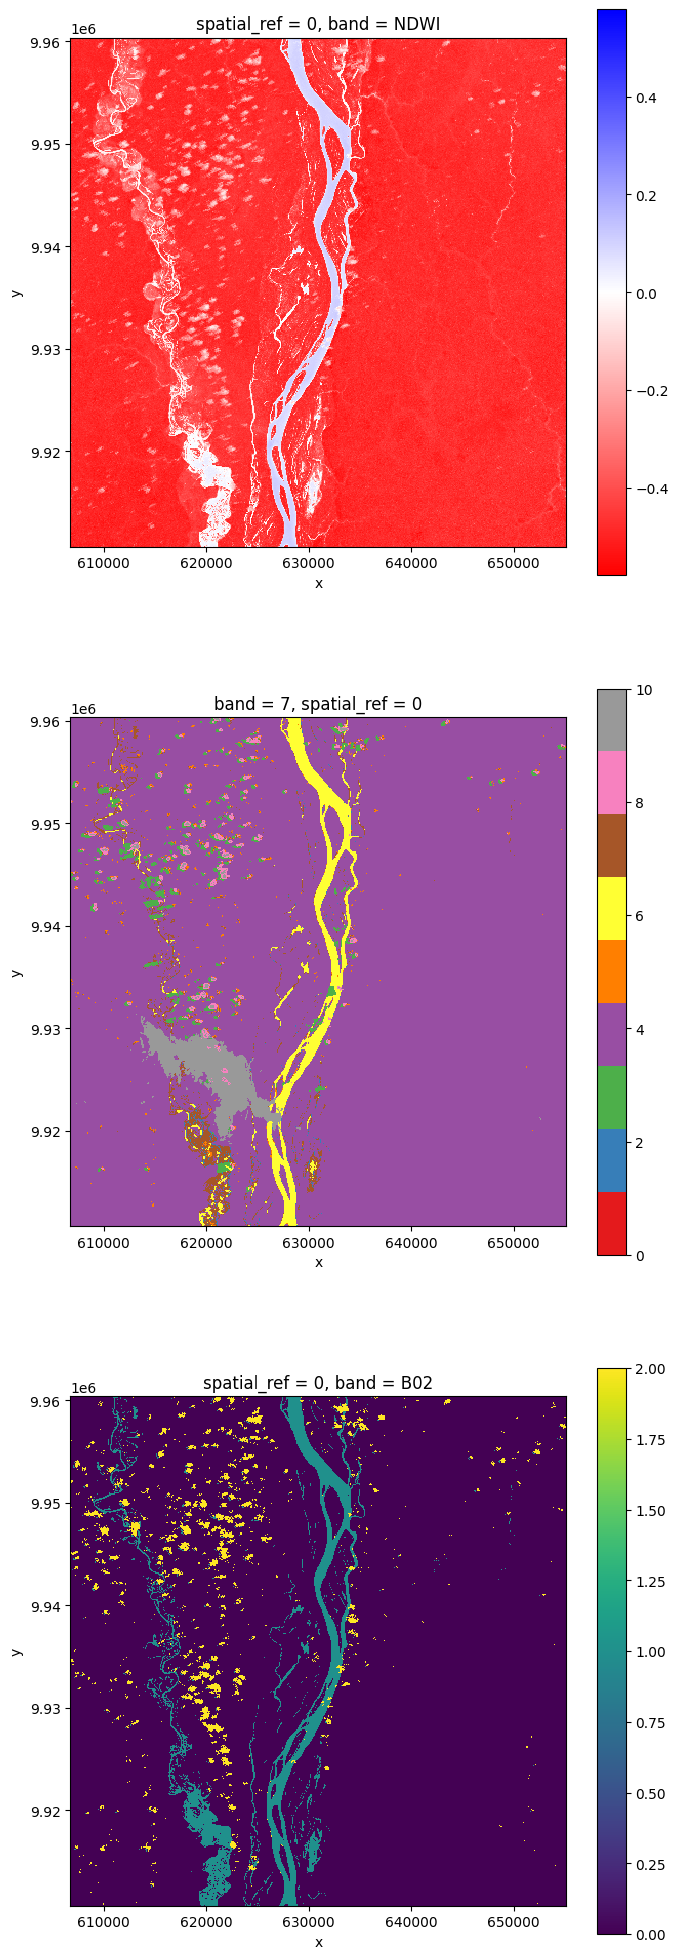

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(8, 25))
s2_img.sel(x=slice(None, None, 10), y=slice(None, None, 10), band="NDWI").plot.imshow(
    cmap="bwr_r", ax=axs[0]
)
scl.sel(x=slice(None, None, 10), y=slice(None, None, 10)).plot.imshow(
    cmap="Set1", vmin=0, vmax=10, ax=axs[1]
)
full_pred.sel(x=slice(None, None, 10), y=slice(None, None, 10)).plot.imshow(ax=axs[2])

for ax in axs:
    ax.set_aspect("equal")

## Post-processing

In [98]:
import rioxarray as xrio

full_pred = xrio.open_rasterio(output_dir / "ref_masks" / f"ref_mask_{_id}.tif").squeeze()

In [79]:
from skimage.morphology import (
    binary_opening,
    closing,
    dilation,
    disk,
    opening,
    remove_small_objects,
    binary_dilation,
)


In [99]:
cls = full_pred.data.copy()
# Binary masks for the classes you want to clean
mask_water = cls == 1
mask_cloud = cls == 2

# Remove small clusters (<4 pixels)
clean_water = remove_small_objects(mask_water, min_size=5, connectivity=1)
clean_cloud = remove_small_objects(mask_cloud, min_size=5, connectivity=1)
clean_cloud = binary_opening(clean_cloud, disk(2))
clean_cloud = dilation(clean_cloud, disk(5))

dilated_water = dilation(clean_water, disk(1))

cls_clean = cls.copy()
# Set removed small components back to background or a null code, e.g., 0
cls_clean[mask_water & ~clean_water] = 0
cls_clean[mask_cloud & ~clean_cloud] = 0
cls_clean[clean_cloud] = 2  # Change cleaned cloud to cloud
cls_clean[dilated_water] = 1  # Change removed water to background

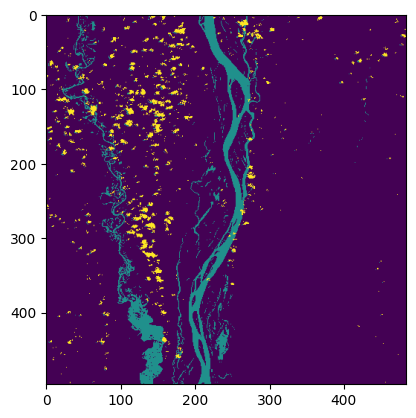

In [26]:
plt.imshow(full_pred.data[::10, ::10])

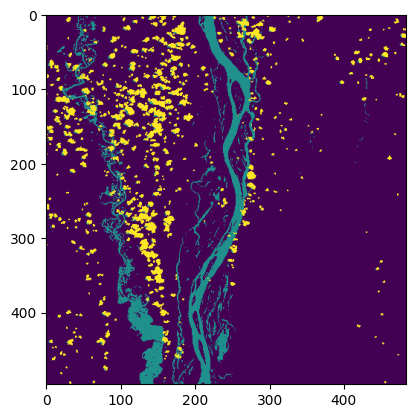

In [94]:
plt.imshow(cls_clean[::10, ::10])

In [ ]:
from pathlib import Path

full_pred.data = cls_clean

_id = s2_ids[DATE]
output_dir = Path(OUTPUT_DIR)

full_pred.rio.to_raster(output_dir / "ref_masks" / f"ref_mask_{_id}_proc.tif", compress="DEFLATE")


In [30]:
disk(5)

array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]], dtype=uint8)

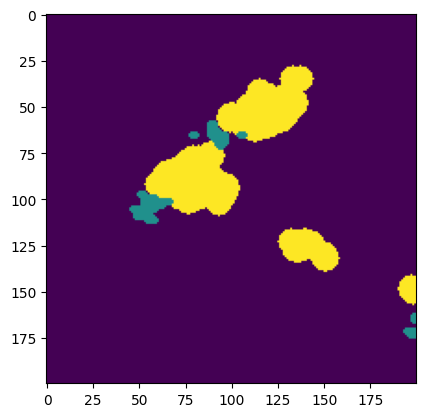

In [100]:
subset = cls_clean[400:600, 100:300].copy()
plt.imshow(subset)

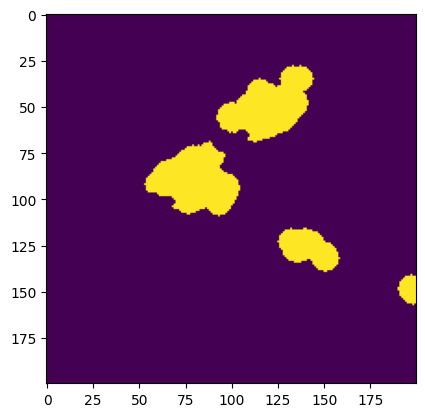

In [47]:
clouds = subset == 2
plt.imshow(clouds)

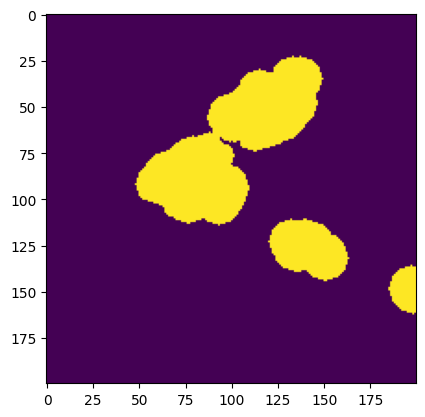

In [48]:
plt.imshow(dilation(clouds, disk(5)))

In [82]:
import numpy as np

footprint = disk(5)


for j in range(11):
    for i in range(11):
        if i > j:
            footprint[j, i] = 0
# footprint = np.zeros((31, 31), dtype="uint8")
footprint

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
       [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]], dtype=uint8)

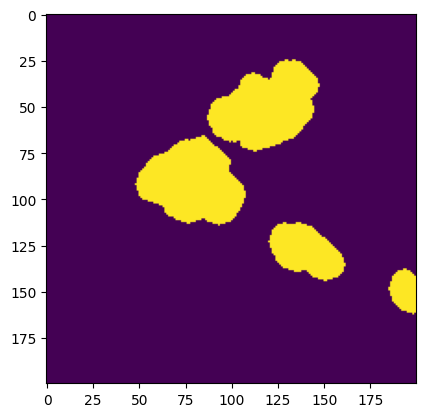

In [83]:
plt.imshow(binary_dilation(clouds, footprint))

In [85]:
d = 18 * 2 + 1
footprint = np.zeros((d, d), dtype="uint8")
footprint[28, 0] = 1

In [101]:
clouds = subset == 2

In [102]:
shadows = binary_dilation(clouds, footprint)

In [103]:
subset2 = subset.copy()

In [104]:
subset2[(subset != 2) & shadows] = 3

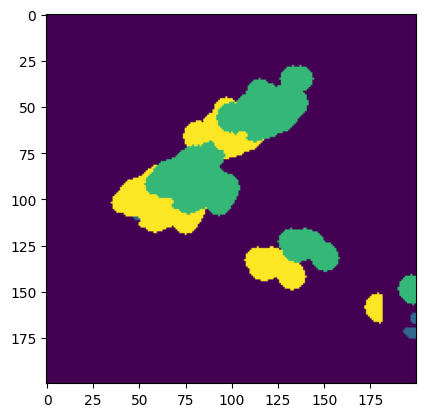

In [105]:
plt.imshow(subset2)

## Scratch

In [ ]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import rioxarray as xrio


In [9]:
s2_ds = s2_img.to_dataset(dim="band")

In [64]:
s2_df = s2_ds.to_dataframe(dim_order=["y", "x"])

In [65]:
s2_df = s2_df.drop(columns=["spatial_ref"])

In [66]:
s2_df.head()

/workspaces/swot/.venv/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


B02       B03       B04       B08       B11  \
y         x                                                            
9960325.0 606785.0  0.136230  0.155273  0.133423  0.469482  0.296631   
          606795.0  0.136230  0.157959  0.133545  0.492432  0.296631   
          606805.0  0.135132  0.159058  0.132812  0.484375  0.310791   
          606815.0  0.138672  0.164185  0.134766  0.500977  0.310791   
          606825.0  0.137451  0.160767  0.135254  0.503906  0.307129   

                         B12      NDVI      NDWI     MNDWI  
y         x                                                 
9960325.0 606785.0  0.178589  0.557617 -0.502930 -0.312744  
          606795.0  0.178589  0.573242 -0.514160 -0.304932  
          606805.0  0.184204  0.569824 -0.505371 -0.322754  
          606815.0  0.184204  0.575684 -0.506348 -0.308594  
          606825.0  0.183472  0.577148 -0.516113 -0.312744

## Train Classifier

In [25]:
from scipy.spatial import cKDTree

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


Here we have one problem... the samples_df has new points created in QGIS that don't have coordinates.<br>
One option is to use the coordinates that we have in the Geometry column, but they will not be aligned correctly
with the coordinates from our raster. In this case we have to find the nearest pixels. 

For that, we will use a cKDTree.


In [35]:
samples_df = gpd.read_file(Path(OUTPUT_DIR) / "training_samples/scl_samples.shp")
samples_df["x"] = samples_df.geometry.x
samples_df["y"] = samples_df.geometry.y

<Axes: >

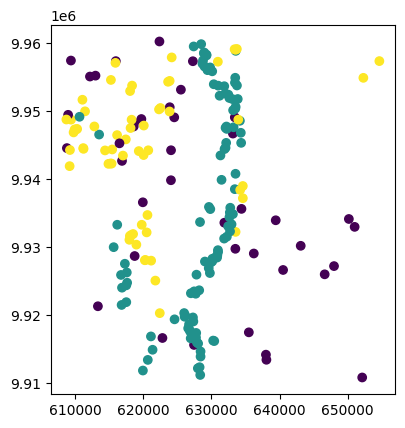

In [61]:
samples_df.plot(column="class")

In [67]:
# Get all the coordinates from the img
img_coords = s2_df.reset_index()[["x", "y"]].values
img_coords

array([[ 606785., 9960325.],
       [ 606795., 9960325.],
       [ 606805., 9960325.],
       ...,
       [ 655075., 9910655.],
       [ 655085., 9910655.],
       [ 655095., 9910655.]], shape=(24005376, 2))

In [68]:
tree = cKDTree(img_coords)

In [69]:
samples_coords = samples_df[["x", "y"]].values

In [70]:
_, idx = tree.query(samples_coords, k=1)

In [71]:
train_x = s2_df.iloc[idx].reset_index(drop=True)
train_x

/workspaces/swot/.venv/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,B02,B03,B04,B08,B11,B12,NDVI,NDWI,MNDWI
0,0.132202,0.142090,0.128540,0.269287,0.184570,0.137085,0.353516,-0.309082,-0.130127
1,0.192383,0.202759,0.184448,0.280762,0.213013,0.169312,0.207031,-0.161133,-0.024536
2,0.140381,0.170044,0.141357,0.455078,0.285156,0.178589,0.526367,-0.456055,-0.252686
3,0.143188,0.163940,0.144043,0.434082,0.261475,0.161255,0.501465,-0.451416,-0.229126
4,0.140015,0.147827,0.137207,0.245972,0.197754,0.181274,0.283936,-0.249390,-0.144409
...,...,...,...,...,...,...,...,...,...
205,0.124512,0.123901,0.120117,0.133789,0.125977,0.115173,0.053955,-0.038422,-0.008400
206,0.131836,0.128906,0.124512,0.130859,0.125488,0.117188,0.025055,-0.007698,0.013367
207,0.126343,0.124878,0.119812,0.134155,0.125732,0.115601,0.056702,-0.035889,-0.003193
208,0.130005,0.128418,0.123413,0.148926,0.135376,0.124329,0.093628,-0.073914,-0.026535


In [72]:
train_y = samples_df["class"].reset_index(drop=True)
train_y

0      2
1      2
2      2
3      2
4      2
      ..
205    1
206    1
207    1
208    1
209    2
Name: class, Length: 210, dtype: int64

In [73]:
clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
clf.fit(train_x, train_y)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
y_pred = clf.predict(train_x)
print(classification_report(train_y, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.85      0.92        40
           1       1.00      1.00      1.00       109
           2       0.91      1.00      0.95        61

    accuracy                           0.97       210
   macro avg       0.97      0.95      0.96       210
weighted avg       0.97      0.97      0.97       210



In [75]:
full_pred = clf.predict(s2_df)

In [77]:
full_pred = full_pred.reshape(s2_img.shape[1], s2_img.shape[2])

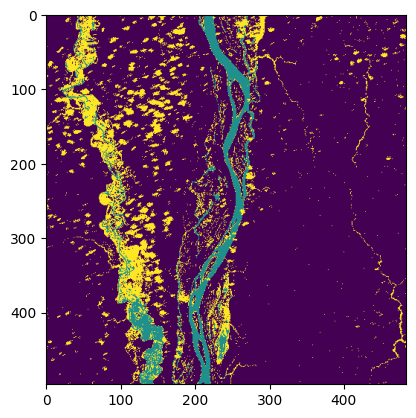

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(full_pred[::10, ::10])

In [79]:
pred_img = scl.where(scl.isnull(), full_pred)

In [82]:
_id = s2_ids[DATE]

In [84]:
pred_img.rio.to_raster(Path(OUTPUT_DIR) / "ref_masks" / f"ref_mask_{_id}.tif", compress="DEFLATE")

### Sample points in each class

In [ ]:
# Create a mapping to simplify the classes

SCL_MAPPING = {
    0: 2,  # No data
    1: 2,  # No data
    2: 2,  # No data
    3: 2,  # Cloud / Shadow
    4: 0,  # No Water
    5: 0,  # No Water
    6: 1,  # Water
    7: 2,  # Cloud / Shadow
    8: 2,  # Cloud / Shadow
    9: 2,  # Cloud / Shadow
    10: 2,  # Cloud / Shadow
    11: 2,  # Cloud / Shadow
}
scl_df["Category"] = scl_df["SCL"].map(SCL_MAPPING)

In [44]:
class_sample_size = {0: 100, 2: 100, 1: 100}  # Example sizes for each class

scl_samp = gpd.GeoDataFrame()
for class_id, size in class_sample_size.items():
    class_samples = scl_df[scl_df["Category"] == class_id].sample(n=size, random_state=42)
    scl_samp = pd.concat([scl_samp, class_samples])

In [45]:
scl_samp = scl_samp.reset_index().drop(columns=["band", "spatial_ref"])

In [46]:
scl_samp = scl_samp.set_geometry(gpd.points_from_xy(scl_samp.x, scl_samp.y))

In [47]:
scl_samp

,x,y,SCL,Category,geometry
0,637695.0,9949535.0,4,0,POINT (637695 9949535)
1,621875.0,9910715.0,4,0,POINT (621875 9910715)
2,652235.0,9926355.0,4,0,POINT (652235 9926355)
3,643995.0,9912245.0,4,0,POINT (643995 9912245)
4,634575.0,9924975.0,4,0,POINT (634575 9924975)
...,...,...,...,...,...
295,629635.0,9935895.0,6,1,POINT (629635 9935895)
296,630955.0,9929545.0,6,1,POINT (630955 9929545)
297,633185.0,9950095.0,6,1,POINT (633185 9950095)
298,633805.0,9939595.0,6,1,POINT (633805 9939595)


<Axes: >

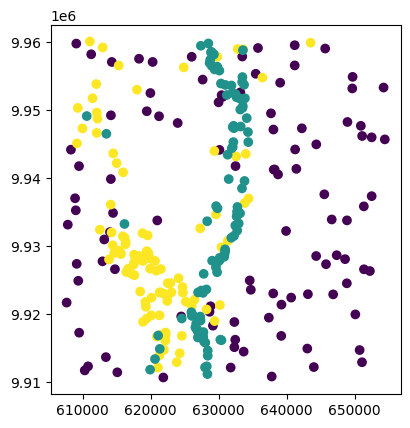

In [49]:
scl_samp.plot(column="Category")

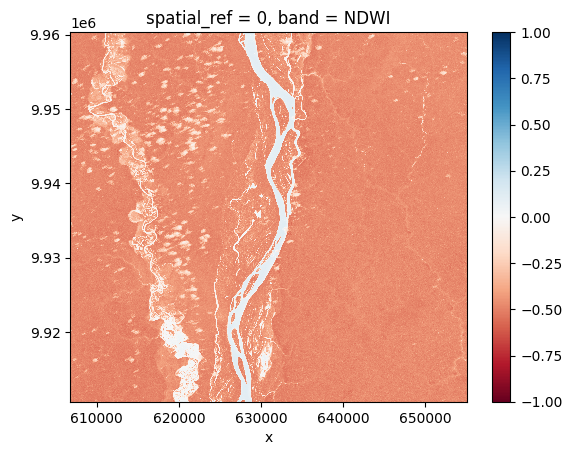

In [20]:
s2_img.sel(band="NDWI").plot(cmap="RdBu", vmin=-1, vmax=1)

In [19]:
s2_img.shape

(9, 4968, 4832)

%